## 1.Import Necessory Libraries

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 2.Import Dataset

In [3]:
claimants_data = pd.read_csv("claimants.csv.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3.Data Understanding

In [4]:
claimants_data.shape

(1340, 7)

In [5]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [1]:
claimants_data.dtypes

NameError: name 'claimants_data' is not defined

## 4.Data Preparation

### 4.1 Data Cleaning

In [10]:
claimants_data.dropna(inplace= True)
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [11]:
1340-1096

244

In [12]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### 4.2 Seperate your inputs and outputs

In [13]:
X = claimants_data.drop(labels = ["CASENUM","ATTORNEY"],axis =1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [14]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5.Model Building

In [15]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=20,random_state=42)

In [16]:
x_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
1228,0.0,1.0,0.0,46.0,1.807
279,0.0,1.0,0.0,47.0,0.150
391,0.0,1.0,0.0,8.0,0.083
568,0.0,1.0,0.0,54.0,1.077
105,0.0,1.0,0.0,43.0,4.485
...,...,...,...,...,...
393,1.0,1.0,0.0,3.0,0.035
572,0.0,1.0,0.0,3.0,0.600
152,1.0,1.0,0.0,6.0,0.075
1275,1.0,1.0,0.0,5.0,0.190


In [17]:
x_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
51,0.0,1.0,0.0,54.0,0.975
694,0.0,1.0,0.0,19.0,0.348
70,0.0,1.0,0.0,56.0,44.060
774,1.0,1.0,0.0,6.0,0.109
595,0.0,1.0,0.0,31.0,5.550
120,1.0,1.0,0.0,10.0,0.305
936,1.0,1.0,0.0,34.0,0.404
64,1.0,1.0,0.0,38.0,1.513
135,0.0,1.0,0.0,1.0,0.080
814,0.0,1.0,0.0,73.0,1.715


In [18]:

logistic_model = LogisticRegression()

## 6.Model Training

In [24]:
logistic_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 7.Model Testing

### Training Data

In [25]:
y_pred_train = logistic_model.predict(x_train)
y_pred_train

array([1, 1, 1, ..., 1, 1, 1], shape=(1076,))

### Testing Data

In [26]:
y_pred_test = logistic_model.predict(x_test)
y_pred_test

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

In [27]:
# claimants_data["Predicted_Output"] = logistic_model.predict(X)
# claimants_data

## 8.Model Evaluation

In [28]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

### Training Data's Evaluation Metrics

In [29]:
print(confusion_matrix(y_train,y_pred_train))

[[371 195]
 [121 389]]


In [30]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.66      0.70       566
           1       0.67      0.76      0.71       510

    accuracy                           0.71      1076
   macro avg       0.71      0.71      0.71      1076
weighted avg       0.71      0.71      0.71      1076



In [31]:
accuracy_score(y_train,y_pred_train)

0.7063197026022305

### ROC Curve - Receiver Operating Characteristics

#### AUC - Area Under this Curve

0.7091110649206678


Text(0, 0.5, 'True Positive Rate')

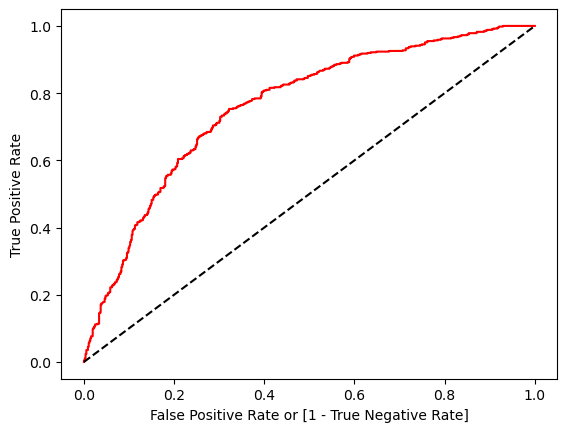

In [32]:
fpr, tpr, thresholds = roc_curve(y_train, logistic_model.predict_proba (x_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### Test Data's Evaluation Metrics

In [33]:
print(confusion_matrix(y_test,y_pred_test))

[[7 5]
 [1 7]]


In [34]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.88      0.58      0.70        12
           1       0.58      0.88      0.70         8

    accuracy                           0.70        20
   macro avg       0.73      0.73      0.70        20
weighted avg       0.76      0.70      0.70        20



In [35]:
accuracy_score(y_test,y_pred_test)

0.7

0.7291666666666665


Text(0, 0.5, 'True Positive Rate')

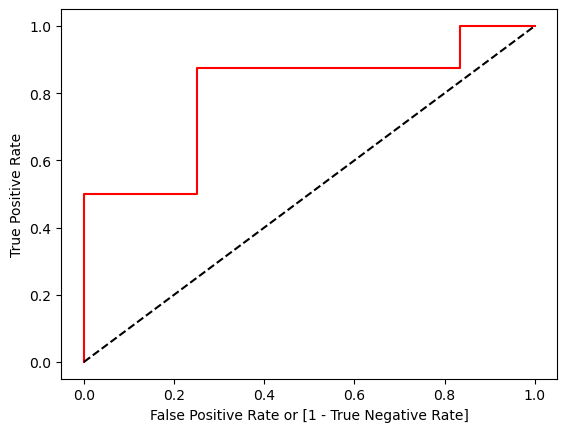

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba (x_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## 9.Model Deployment

In [31]:
from pickle import dump

In [32]:
dump(logistic_model,open("claimants.pkl","wb"))

# THE END !!!